In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot, plot_yearly, plot_weekly
from prophet.diagnostics import cross_validation

from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [59]:
plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

## 19.3 Basic forecasting with Prophet 

In [60]:
df = pd.read_csv('../data/daily_min_temp.csv')

df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [61]:
df.tail()

,Date,Temp
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7
3649,1990-12-31,13.0


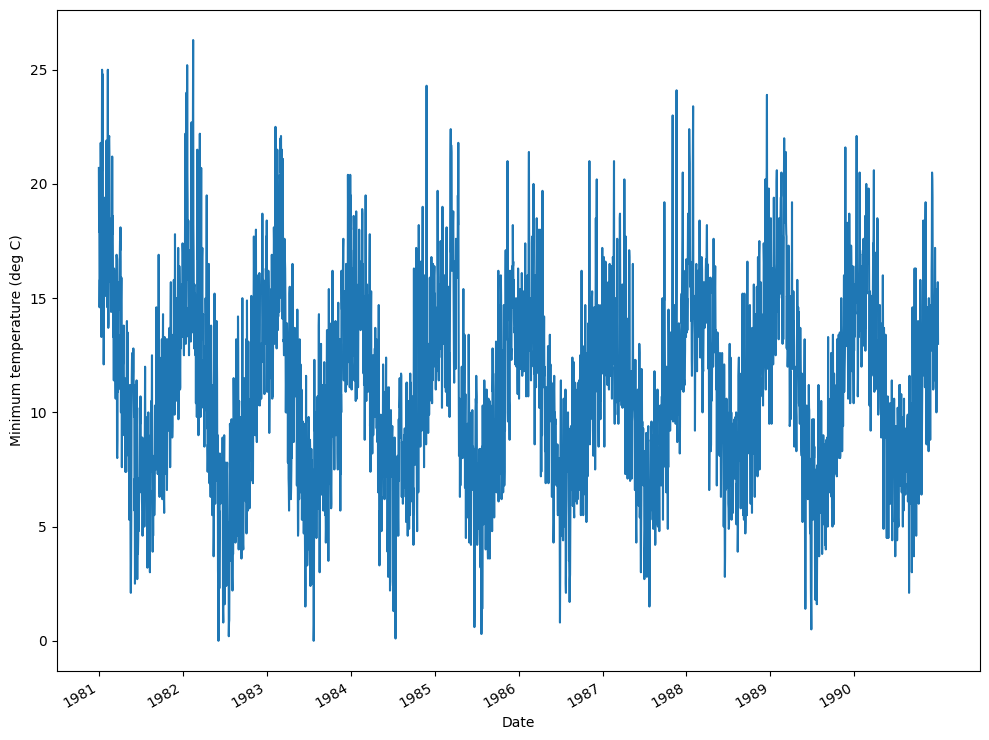

In [62]:
fig, ax = plt.subplots()

ax.plot(df['Temp'])
ax.set_xlabel('Date')
ax.set_ylabel('Minimum temperature (deg C)')

plt.xticks(np.arange(0, 3649, 365), np.arange(1981, 1991, 1))

fig.autofmt_xdate()
plt.tight_layout()

## Basic forecasting with Prophet

In [63]:
df.columns = ['ds', 'y']
df.head()

,ds,y
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [64]:
train = df[:-365]
test = df[-365:]

In [65]:
m = Prophet()

In [66]:
m.fit(train)

07:25:50 - cmdstanpy - INFO - Chain [1] start processing
07:25:51 - cmdstanpy - INFO - Chain [1] done processing


In [67]:
future = m.make_future_dataframe(periods=365)

In [68]:
forecast = m.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].iloc[-365:-360]

,ds,yhat,yhat_lower,yhat_upper
3285,1990-01-01,14.886092,11.280261,18.438053
3286,1990-01-02,15.012606,11.243240,18.343653
3287,1990-01-03,15.089069,11.676761,18.650250
3288,1990-01-04,14.997204,11.596818,18.397801
3289,1990-01-05,15.067524,11.374315,18.420393


In [69]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
3645,1990-12-27,11.410439,10.981120,18.031842,11.315813,11.505242,3.043447,3.043447,3.043447,-0.026429,-0.026429,-0.026429,3.069876,3.069876,3.069876,0.0,0.0,0.0,14.453885
3646,1990-12-28,11.410359,10.991983,17.955096,11.315326,11.505465,3.120799,3.120799,3.120799,-0.009954,-0.009954,-0.009954,3.130753,3.130753,3.130753,0.0,0.0,0.0,14.531158
3647,1990-12-29,11.410280,11.080736,18.264687,11.314730,11.505922,3.144872,3.144872,3.144872,-0.048867,-0.048867,-0.048867,3.193738,3.193738,3.193738,0.0,0.0,0.0,14.555152
3648,1990-12-30,11.410201,11.077382,18.083530,11.314138,11.506099,3.069365,3.069365,3.069365,-0.188713,-0.188713,-0.188713,3.258079,3.258079,3.258079,0.0,0.0,0.0,14.479566
3649,1990-12-31,11.410122,11.092568,18.034930,11.313549,11.506204,3.366603,3.366603,3.366603,0.043643,0.043643,0.043643,3.322961,3.322961,3.322961,0.0,0.0,0.0,14.776726


In [70]:
test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]
test.head()

,ds,y,yhat,yhat_lower,yhat_upper
3285,1990-01-01,14.8,14.886092,11.280261,18.438053
3286,1990-01-02,13.3,15.012606,11.243240,18.343653
3287,1990-01-03,15.6,15.089069,11.676761,18.650250
3288,1990-01-04,14.5,14.997204,11.596818,18.397801
3289,1990-01-05,14.3,15.067524,11.374315,18.420393


In [71]:
test['baseline'] = train['y'][-365:].values
test.head()

,ds,y,yhat,yhat_lower,yhat_upper,baseline
3285,1990-01-01,14.8,14.886092,11.280261,18.438053,14.3
3286,1990-01-02,13.3,15.012606,11.243240,18.343653,17.4
3287,1990-01-03,15.6,15.089069,11.676761,18.650250,18.5
3288,1990-01-04,14.5,14.997204,11.596818,18.397801,16.8
3289,1990-01-05,14.3,15.067524,11.374315,18.420393,11.5


In [72]:
prophet_mae = mean_absolute_error(test['y'], test['yhat'])
baseline_mae = mean_absolute_error(test['y'], test['baseline'])

print(prophet_mae)
print(baseline_mae)

1.9371482051863482
2.8673972602739726


In [73]:
test.iloc[59]

ds            1990-03-01
y                   19.3
yhat           15.471506
yhat_lower     11.941698
yhat_upper     19.008559
baseline            20.4
Name: 3344, dtype: object

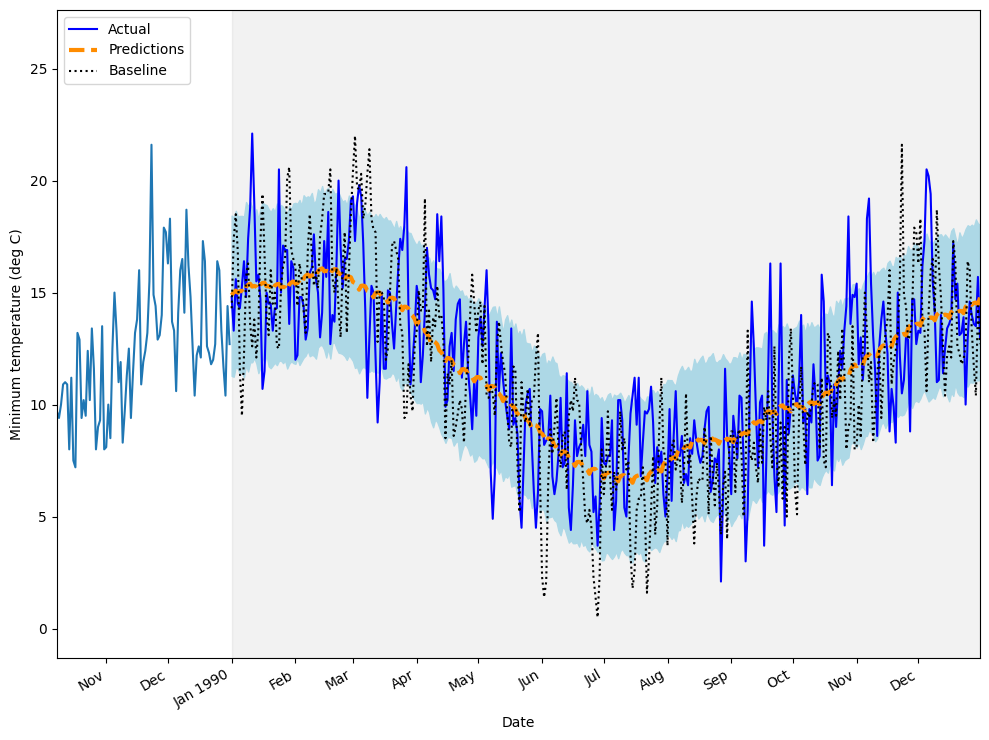

In [74]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='Actual')
ax.plot(test['yhat'], color='darkorange', ls='--', lw=3, label='Predictions')
ax.plot(test['baseline'], 'k:', label='Baseline')

ax.set_xlabel('Date')
ax.set_ylabel('Minimum temperature (deg C)')

ax.axvspan(3285, 3649, color='#808080', alpha=0.1)

ax.legend(loc='best')

plt.xticks(
    [3224, 3254, 3285, 3316, 3344, 3375, 3405, 3436, 3466, 3497, 3528, 3558, 3589, 3619],
    ['Nov', 'Dec', 'Jan 1990', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(3200, 3649)

fig.autofmt_xdate()
plt.tight_layout()

## 19.4 Exploring Prophet's advanced functionalities

### 19.4.1 Visualization capabilities

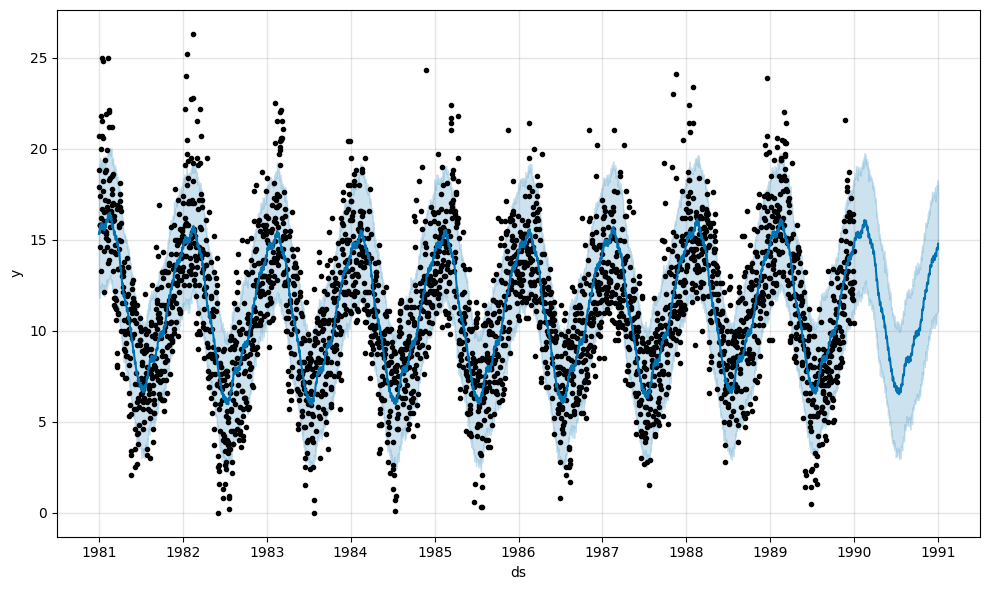

In [75]:
fig1 = m.plot(forecast)

#### Plot components 

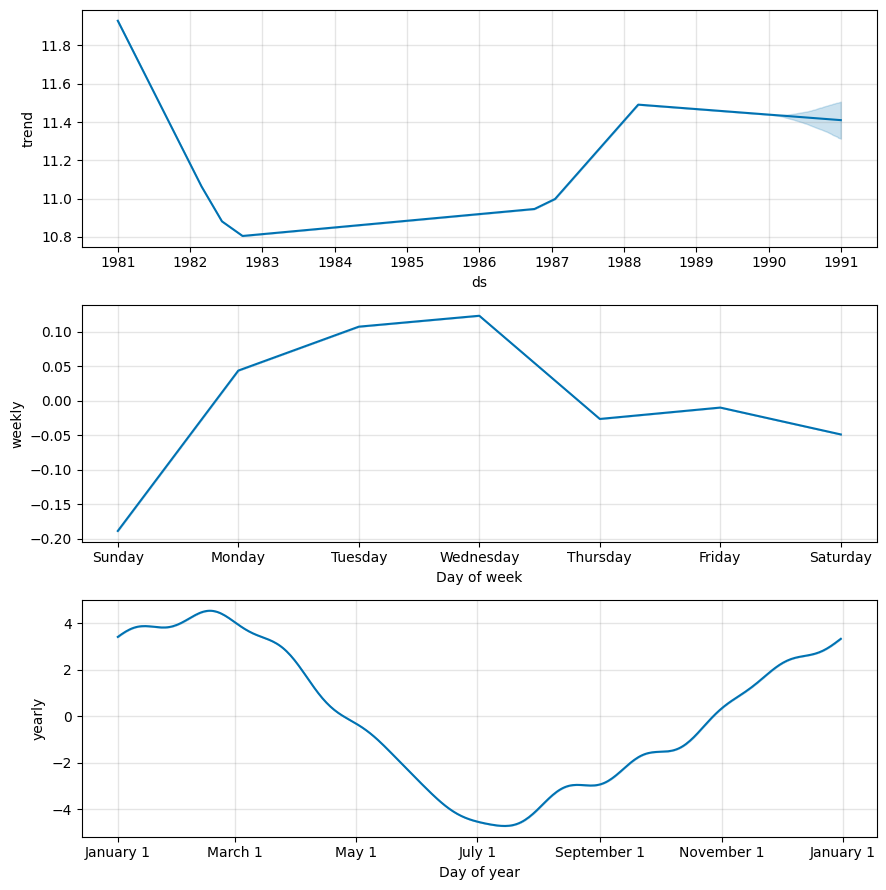

In [76]:
fig2 = m.plot_components(forecast)

#### Show trend changepoints 

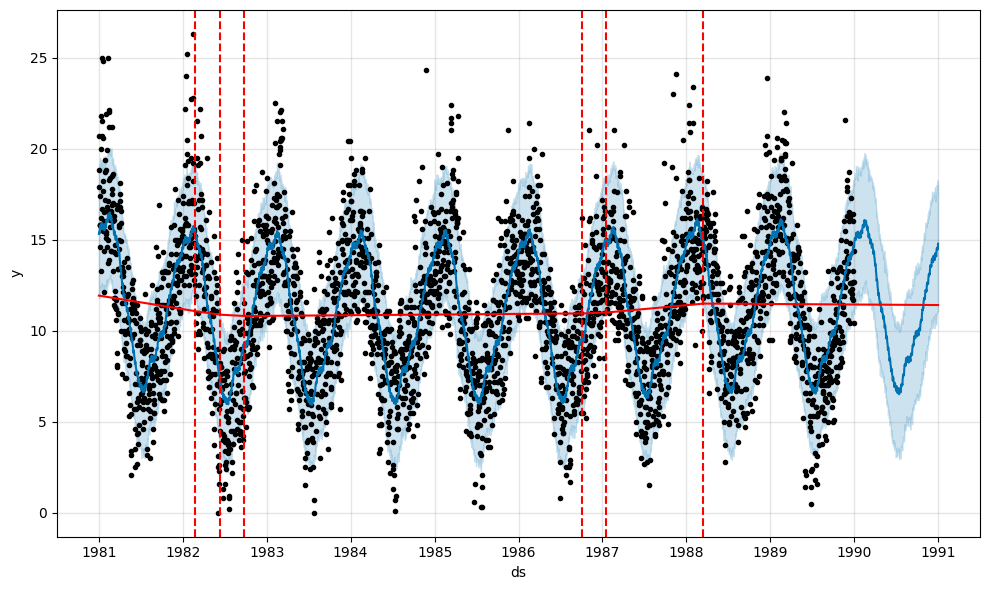

In [77]:
fig3 = m.plot(forecast)
a = add_changepoints_to_plot(fig3.gca(), m, forecast)

#### Plot seasonal components 

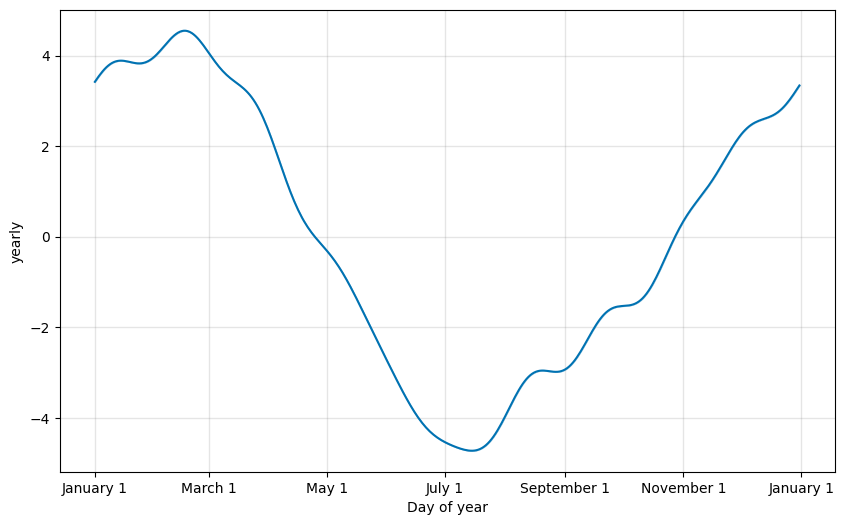

In [78]:
fig4 = plot_yearly(m)

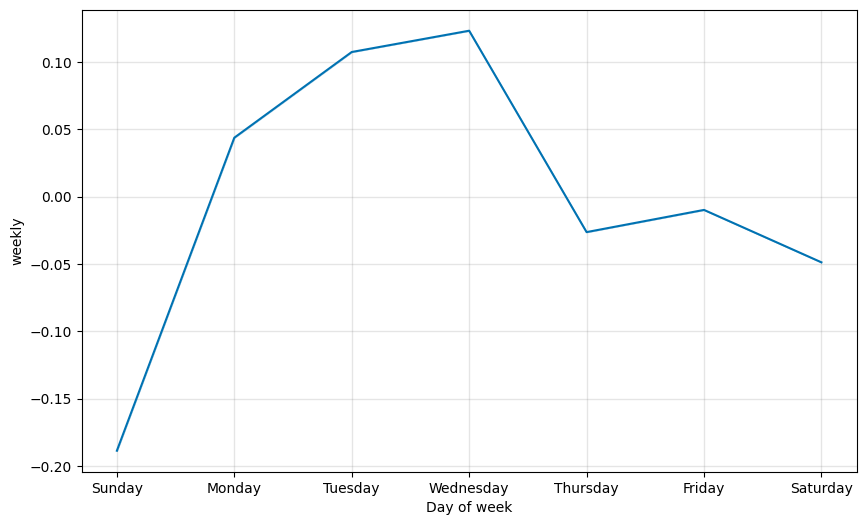

In [79]:
fig5 = plot_weekly(m)

07:26:13 - cmdstanpy - INFO - Chain [1] start processing
07:26:14 - cmdstanpy - INFO - Chain [1] done processing


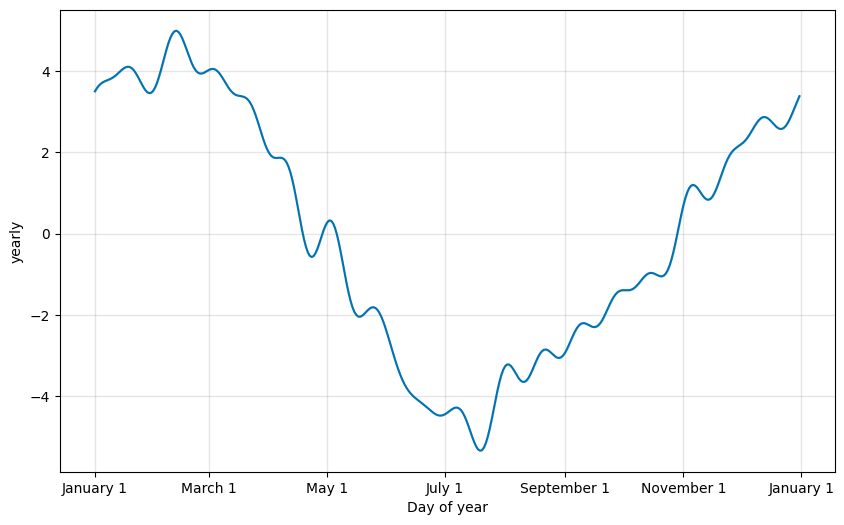

In [80]:
m2 = Prophet(yearly_seasonality=20).fit(train)

fig6 = plot_yearly(m2)

### 19.4.2 Cross-validation and performance metrics

In [81]:
df_cv = cross_validation(m, initial='730 days', period='180 days', horizon='365 days', parallel='processes')

df_cv.head()

07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] done processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] done processing
07:26:16 - cmdstanpy - INFO - Chain [1] done processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] start processing
07:26:16 - cmdstanpy - INFO - Chain [1] done processing
07:26:16 - cmdstanpy - INFO - Chain [1] done processing
07:26:16 - cmdstanpy - INFO - Chain 

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1983-02-02,15.153383,11.572386,18.871806,17.3,1983-02-01
1,1983-02-03,14.814921,11.381896,18.332169,13.0,1983-02-01
2,1983-02-04,15.209705,11.646567,18.704330,16.0,1983-02-01
3,1983-02-05,15.200569,11.710065,18.787680,14.9,1983-02-01
4,1983-02-06,15.247281,11.702298,18.858523,16.2,1983-02-01


In [82]:
from prophet.diagnostics import performance_metrics

df_perf = performance_metrics(df_cv, rolling_window=0)

df_perf.head()

,horizon,mse,rmse,mae,mdape,smape,coverage
0,1 days,6.334269,2.516797,2.066210,0.147147,0.197643,0.846154
1,2 days,4.628198,2.151325,1.736320,0.139609,0.160417,0.846154
2,3 days,9.992974,3.161166,2.657326,0.147113,0.371661,0.769231
3,4 days,8.647353,2.940638,2.373635,0.196617,0.328771,0.769231
4,5 days,8.268383,2.875480,2.574436,0.195980,0.302032,0.692308


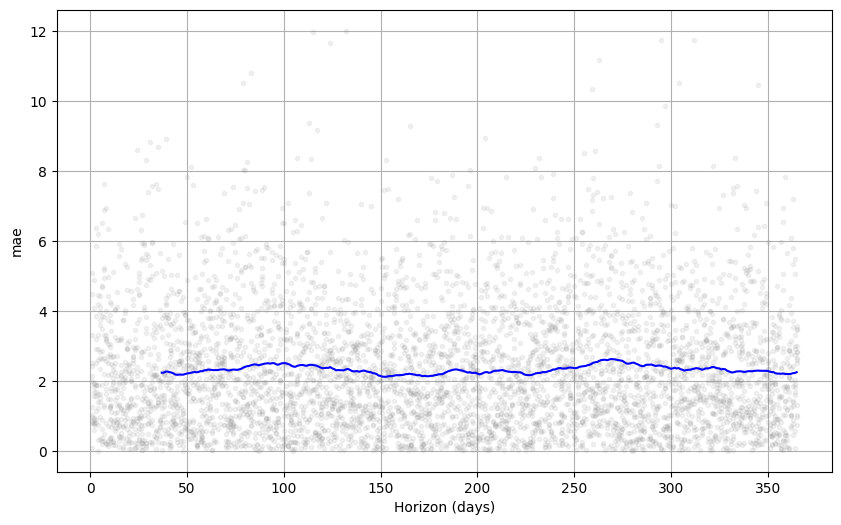

In [83]:
def plot_cross_validation_metric(df_cv, metric='mape', rolling_window=0.1,
                                 ax=None, figsize=(10, 6), color='b', point_color='gray'):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # Rolling Average를 적용하지 않은 성능 지표 계산
    #
    # 각 Horizon에서의 원본 성능값
    df_none = performance_metrics(df_cv, metrics=[metric], rolling_window=-1)

    # Rolling Average를 적용한 성능 지표 계산
    #
    # 부드러운 추세선 생성
    df_h = performance_metrics(df_cv, metrics=[metric], rolling_window=rolling_window)

    tick_w = max(df_none['horizon'].astype('timedelta64[ns]')) / 10.
    dts = ['D', 'h', 'm', 's', 'ms', 'us', 'ns']
    dt_names = ['days', 'hours', 'minutes', 'seconds', 'milliseconds', 'microseconds', 'nanoseconds']
    dt_conversions = [24*60*60*10**9, 60*60*10**9, 60*10**9, 10**9, 10**6, 10**3, 1.]
    for i, dt in enumerate(dts):
        if np.timedelta64(1, dt) < np.timedelta64(tick_w, 'ns'):
            break

    x_plt = np.asarray(df_none['horizon'].astype('timedelta64[ns]')).view(np.int64) / float(dt_conversions[i])
    x_plt_h = np.asarray(df_h['horizon'].astype('timedelta64[ns]')).view(np.int64) / float(dt_conversions[i])

    ax.plot(x_plt, df_none[metric], '.', alpha=0.1, c=point_color)
    ax.plot(x_plt_h, df_h[metric], '-', c=color)
    ax.grid(True)
    ax.set_xlabel(f'Horizon ({dt_names[i]})')
    ax.set_ylabel(metric)
    return fig

fig7 = plot_cross_validation_metric(df_cv, metric='mae')

### 19.4.3 Hyperparameter tuning 

In [84]:
from itertools import product

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0]
}

all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

maes = []

for params in all_params:
    m = Prophet(**params).fit(train)
    df_cv = cross_validation(m, initial='730 days', period='180 days', horizon='365 days', parallel='processes')
    df_p = performance_metrics(df_cv, rolling_window=1)
    maes.append(df_p['mae'].values[0])
    
tuning_results = pd.DataFrame(all_params)
tuning_results['mae'] = maes

tuning_results

07:26:18 - cmdstanpy - INFO - Chain [1] start processing
07:26:18 - cmdstanpy - INFO - Chain [1] done processing
07:26:19 - cmdstanpy - INFO - Chain [1] start processing
07:26:19 - cmdstanpy - INFO - Chain [1] start processing
07:26:19 - cmdstanpy - INFO - Chain [1] done processing
07:26:19 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
07:26:19 - cmdstanpy - INFO - Chain [1] start processing
07:26:19 - cmdstanpy - INFO - Chain [1] start processing
07:26:19 - cmdstanpy - INFO - Chain [1] done processing
07:26:19 - cmdstanpy - INFO - Chain [1] start processing
07:26:19 - cmdstanpy - INFO - Chain [1] start processing
07:26:19 - cmdstanpy - INFO - Chain [1] start processing
07:26:19 - cmdstanpy - INFO - Chain [1] done processing
07:26:19 - cmdstanpy - INFO - Chain [1] done processing
07:26:19 - cmdstanpy - INFO - Chain [1] done processing
07:26:19 - cmdstanpy - INFO - Chain [1] start processing
07:26:19 -

,changepoint_prior_scale,seasonality_prior_scale,mae
0,0.001,0.01,2.304710
1,0.001,0.10,2.308774
2,0.001,1.00,2.342149
3,0.001,10.00,2.343577
4,0.010,0.01,2.238849
5,0.010,0.10,2.278535
6,0.010,1.00,2.276390
7,0.010,10.00,2.281593
8,0.100,0.01,2.682633
9,0.100,0.10,2.347282


In [85]:
best_params = all_params[np.argmin(maes)]
print(best_params)

{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01}


## 19.5 Implementing a robust forecasting process with Prophet 

### 19.5.1 Forecasting project: Predicting the popularity of "chocolate" searches on Google 

Source: https://trends.google.com/trends/explore?date=all&geo=US&q=chocolate

In [86]:
df = pd.read_csv('../data/monthly_chocolate_search_usa.csv')
df.head()

,month,chocolate
0,2004-01,35
1,2004-02,48
2,2004-03,34
3,2004-04,33
4,2004-05,33


In [87]:
df.tail()

,month,chocolate
211,2021-08,45
212,2021-09,45
213,2021-10,44
214,2021-11,54
215,2021-12,74


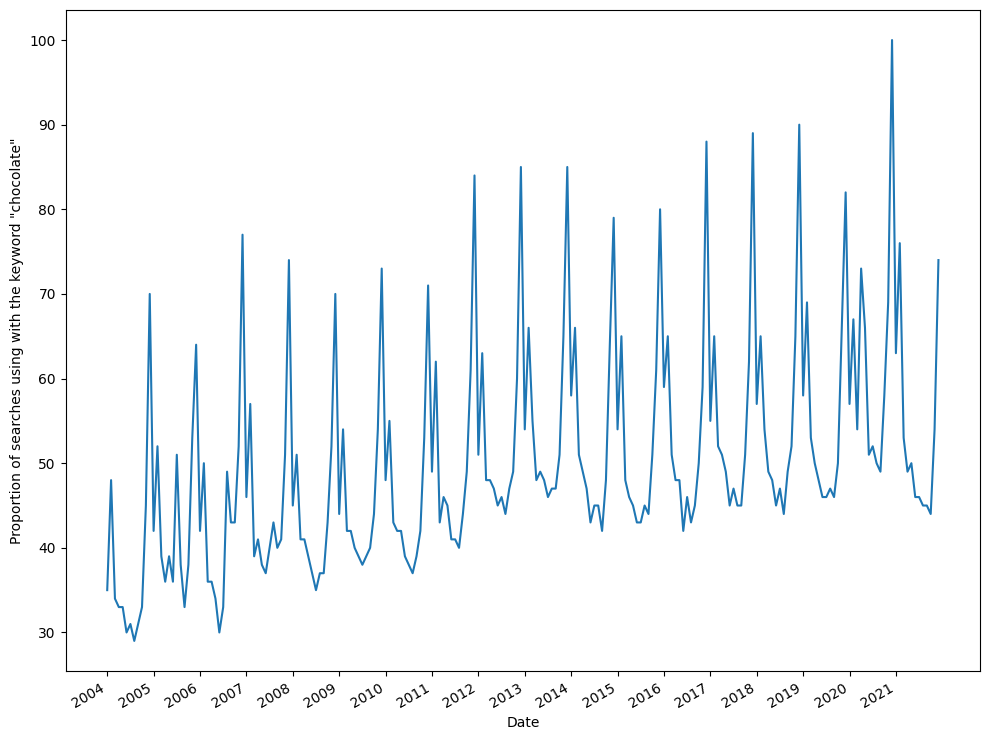

In [88]:
fig, ax = plt.subplots()

ax.plot(df['chocolate'])
ax.set_xlabel('Date')
ax.set_ylabel('Proportion of searches using with the keyword "chocolate"')

plt.xticks(np.arange(0, 215, 12), np.arange(2004, 2022, 1))

fig.autofmt_xdate()
plt.tight_layout()

In [89]:
df.columns = ['ds', 'y']
df.head()

,ds,y
0,2004-01,35
1,2004-02,48
2,2004-03,34
3,2004-04,33
4,2004-05,33


In [90]:
from pandas.tseries.offsets import MonthEnd

df['ds'] = pd.to_datetime(df['ds']) + MonthEnd(1)

df.head()

,ds,y
0,2004-01-31,35
1,2004-02-29,48
2,2004-03-31,34
3,2004-04-30,33
4,2004-05-31,33


In [91]:
train = df[:-12]
test = df[-12:]

In [92]:
train.tail()

,ds,y
199,2020-08-31,50
200,2020-09-30,49
201,2020-10-31,58
202,2020-11-30,69
203,2020-12-31,100


In [93]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0]
}

params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

mses = []

cutoffs = pd.date_range(start='2009-01-31', end=train['ds'].max() - pd.Timedelta('365 days'), freq='12ME')

for param in params:
    m = Prophet(**param)
    m.add_country_holidays(country_name='US')
    m.fit(train)
    
    df_cv = cross_validation(model=m, horizon='365 days', cutoffs=cutoffs)
    df_p = performance_metrics(df_cv, rolling_window=1)
    mses.append(df_p['mse'].values[0])
    
tuning_results = pd.DataFrame(params)
tuning_results['mse'] = mses

07:26:42 - cmdstanpy - INFO - Chain [1] start processing
07:26:42 - cmdstanpy - INFO - Chain [1] done processing
07:26:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
07:26:42 - cmdstanpy - INFO - Chain [1] start processing
07:26:42 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/11 [00:00<?, ?it/s]07:26:42 - cmdstanpy - INFO - Chain [1] start processing
07:26:42 - cmdstanpy - INFO - Chain [1] done processing
  9%|▉         | 1/11 [00:00<00:01,  7.95it/s]07:26:42 - cmdstanpy - INFO - Chain [1] start processing
07:26:43 - cmdstanpy - INFO - Chain [1] done processing
 18%|█▊        | 2/11 [00:00<00:03,  2.32it/s]07:26:43 - cmdstanpy - INFO - Chain [1] start processing
07:26:43 - cmdstanpy - INFO - Chain [1] done processing
 27%|██▋       | 3/11 [00:01<00:03,  2.04it/s]07:26:43 - cmdstanpy - INFO - Chain [1] start processing
07:26:43 - cmdstanpy - INFO - Chain [1] done processing
 36%|

In [94]:
best_params = params[np.argmin(mses)]
print(best_params)

{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1}


In [95]:
m = Prophet(**best_params)
m.add_country_holidays(country_name='US')
m.fit(train)

07:27:05 - cmdstanpy - INFO - Chain [1] start processing
07:27:05 - cmdstanpy - INFO - Chain [1] done processing


In [96]:
future = m.make_future_dataframe(periods=12, freq='ME')

In [97]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
204,2021-01-31,60.838772,56.137724,65.258875
205,2021-02-28,70.130538,65.256141,74.651996
206,2021-03-31,56.361020,51.762060,60.995675
207,2021-04-30,56.232568,51.436670,60.509696
208,2021-05-31,53.435487,48.813764,58.059421
209,2021-06-30,51.322677,46.626337,55.803705
210,2021-07-31,53.035638,48.274677,57.394051
211,2021-08-31,52.739047,48.511302,57.214644
212,2021-09-30,52.766810,48.200484,57.327366
213,2021-10-31,57.013643,52.445765,61.873612


In [98]:
test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]
test.head()

,ds,y,yhat,yhat_lower,yhat_upper
204,2021-01-31,63,60.838772,56.137724,65.258875
205,2021-02-28,76,70.130538,65.256141,74.651996
206,2021-03-31,53,56.361020,51.762060,60.995675
207,2021-04-30,49,56.232568,51.436670,60.509696
208,2021-05-31,50,53.435487,48.813764,58.059421


In [99]:
test['baseline'] = train['y'][-12:].values
test.head()

,ds,y,yhat,yhat_lower,yhat_upper,baseline
204,2021-01-31,63,60.838772,56.137724,65.258875,57
205,2021-02-28,76,70.130538,65.256141,74.651996,67
206,2021-03-31,53,56.361020,51.762060,60.995675,54
207,2021-04-30,49,56.232568,51.436670,60.509696,73
208,2021-05-31,50,53.435487,48.813764,58.059421,66


In [100]:
prophet_mae = mean_absolute_error(test['y'], test['yhat'])
baseline_mae = mean_absolute_error(test['y'], test['baseline'])

print(prophet_mae)
print(baseline_mae)

7.41148790901842
10.916666666666666


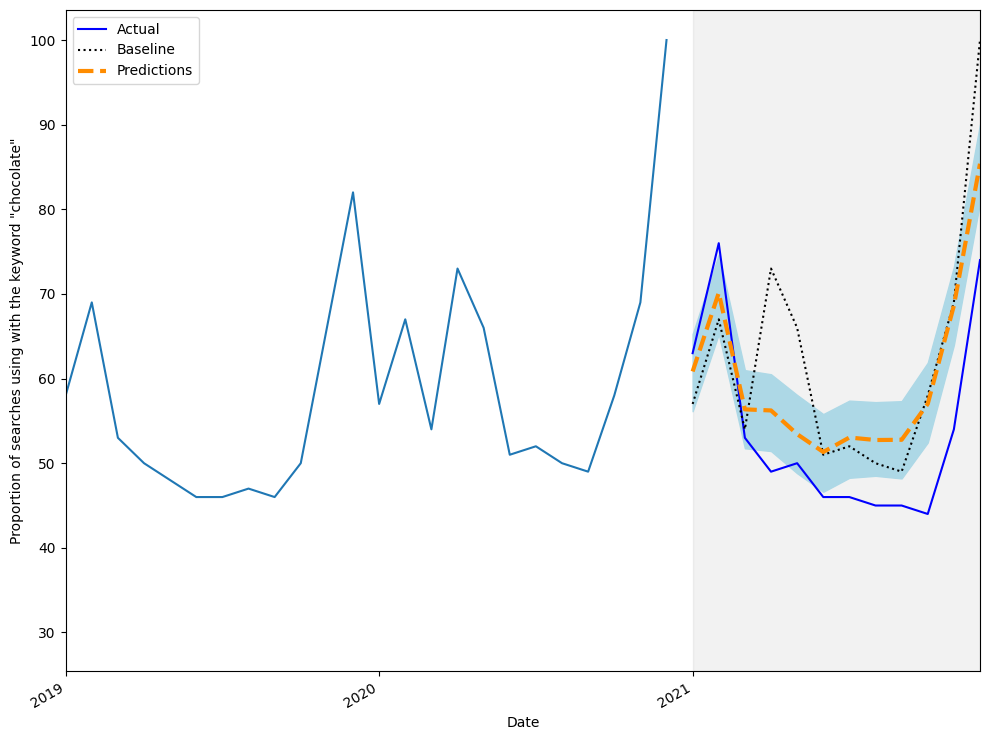

In [101]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='Actual')
ax.plot(test['baseline'], 'k:', label='Baseline')
ax.plot(test['yhat'], color='darkorange', ls='--', lw=3, label='Predictions')

ax.set_xlabel('Date')
ax.set_ylabel('Proportion of searches using with the keyword "chocolate"')

ax.axvspan(204, 215, color='#808080', alpha=0.1)

ax.legend(loc='best')

plt.xticks(np.arange(0, 215, 12), np.arange(2004, 2022, 1))
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(180, 215)

fig.autofmt_xdate()
plt.tight_layout()

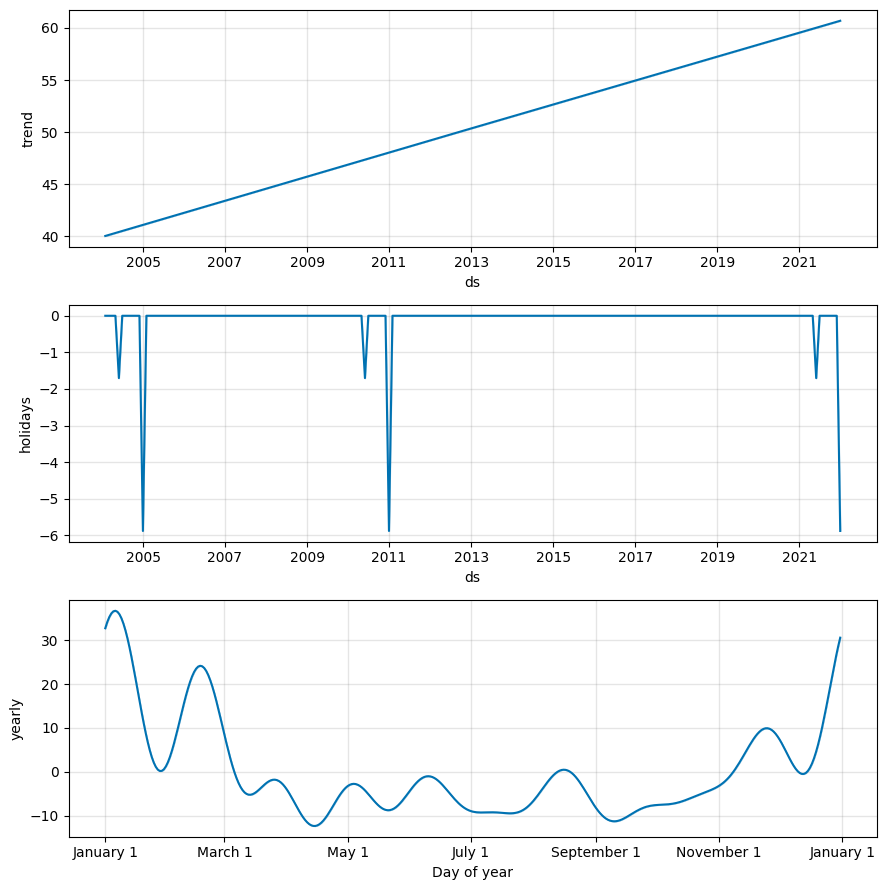

In [102]:
prophet_components_fig = m.plot_components(forecast)

### 19.5.2 Experiment: Can SARIMA do better? 

In [103]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm
from itertools import product
from typing import Union

In [104]:
ad_fuller_result = adfuller(df['y'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.034174339601257
p-value: 0.27179271331669036


In [105]:
y_diff = np.diff(df['y'], n=1)

ad_fuller_result = adfuller(y_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -7.034710505102191
p-value: 6.058003360042041e-10


$d=1$, $D=0$ and $m=12$

In [106]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [107]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
Ps = range(0, 4, 1)
Qs = range(0, 4, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 1
D = 0
s = 12

In [108]:
SARIMA_result_df = optimize_SARIMAX(train['y'], None, order_list, d, D, s)
SARIMA_result_df

100%|██████████| 256/256 [02:05<00:00,  2.04it/s]


,"(p,q,P,Q)",AIC
0,"(1, 1, 1, 1)",1127.835901
1,"(1, 2, 1, 1)",1128.989156
2,"(1, 1, 1, 2)",1129.724438
3,"(0, 2, 1, 1)",1130.167390
4,"(1, 3, 1, 1)",1130.673841
...,...,...
245,"(1, 2, 0, 0)",1570.730422
246,"(2, 1, 0, 0)",1570.732139
247,"(0, 1, 0, 0)",1570.979692
248,"(0, 2, 0, 0)",1571.866177


In [109]:
SARIMA_model = SARIMAX(train['y'], order=(1,1,1), seasonal_order=(1,0,1,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  204
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -558.918
Date:                            Fri, 26 Jun 2026   AIC                           1127.836
Time:                                    07:29:11   BIC                           1144.402
Sample:                                         0   HQIC                          1134.538
                                            - 204                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3516      0.088      4.006      0.000       0.180       0.524
ma.L1         -0.8913      0.056   

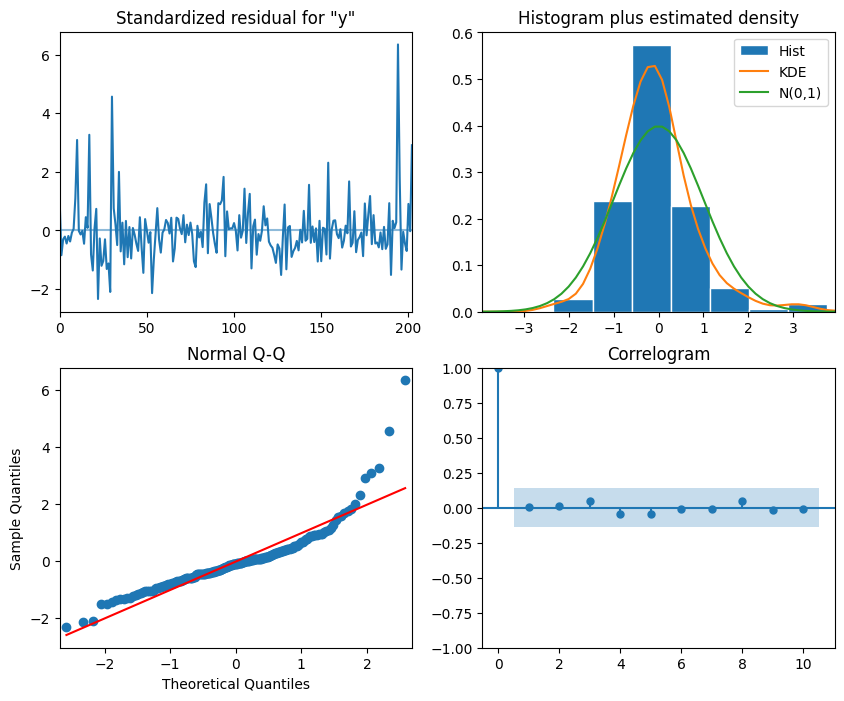

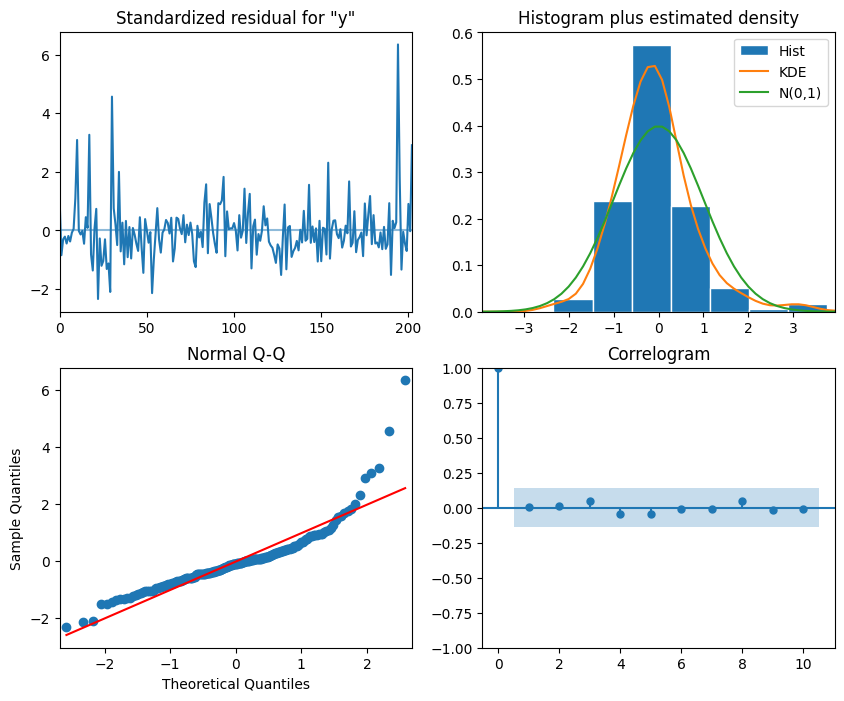

In [110]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8))

In [111]:
residuals = SARIMA_model_fit.resid

lb_result = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1))

pvalue = lb_result['lb_pvalue'].to_numpy()

print(pvalue)

[0.04392211 0.09002524 0.18460169 0.23254253 0.22985668 0.28549465
 0.38786862 0.48442296 0.50383578 0.26124943]


In [112]:
test

,ds,y,yhat,yhat_lower,yhat_upper,baseline
204,2021-01-31,63,60.838772,56.137724,65.258875,57
205,2021-02-28,76,70.130538,65.256141,74.651996,67
206,2021-03-31,53,56.361020,51.762060,60.995675,54
207,2021-04-30,49,56.232568,51.436670,60.509696,73
208,2021-05-31,50,53.435487,48.813764,58.059421,66
209,2021-06-30,46,51.322677,46.626337,55.803705,51
210,2021-07-31,46,53.035638,48.274677,57.394051,52
211,2021-08-31,45,52.739047,48.511302,57.214644,50
212,2021-09-30,45,52.766810,48.200484,57.327366,49
213,2021-10-31,44,57.013643,52.445765,61.873612,58


In [113]:
SARIMA_pred = SARIMA_model_fit.get_prediction(204, 215).predicted_mean

test['SARIMA_pred'] = SARIMA_pred

test

,ds,y,yhat,yhat_lower,yhat_upper,baseline,SARIMA_pred
204,2021-01-31,63,60.838772,56.137724,65.258875,57,66.614451
205,2021-02-28,76,70.130538,65.256141,74.651996,67,74.253274
206,2021-03-31,53,56.361020,51.762060,60.995675,54,59.851544
207,2021-04-30,49,56.232568,51.436670,60.509696,73,60.858019
208,2021-05-31,50,53.435487,48.813764,58.059421,66,58.699150
209,2021-06-30,46,51.322677,46.626337,55.803705,51,53.747363
210,2021-07-31,46,53.035638,48.274677,57.394051,52,54.995212
211,2021-08-31,45,52.739047,48.511302,57.214644,50,54.230812
212,2021-09-30,45,52.766810,48.200484,57.327366,49,54.544156
213,2021-10-31,44,57.013643,52.445765,61.873612,58,59.610830


In [114]:
SARIMA_mae = mean_absolute_error(test['y'], test['SARIMA_pred'])

print(SARIMA_mae)

10.167719773367518
